

Student: Chitranjan Vishwakarma
College: Sri Ram Kishun P.G College, Gokul, Karsada, Varanasi  
AICTE Student ID: STU6a6aca966acaf1785383574

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

PALETTE = ["#2E5EAA", "#4FB0C6", "#F2A541", "#E8594F", "#6BBF59", "#8B5FBF"]
sns.set_palette(sns.color_palette(PALETTE))

Libraries loaded successfully!


# 1. Loading the Dataset

In [ ]:
# For load / read the file
df = pd.read_csv("Healthcare_Analytics_for_Doctor_Visits.csv")
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (5190, 15)


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,age_years,income_thousands,age_group
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no,19,5500.0,19-30
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no,19,4500.0,19-30
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no,19,9000.0,19-30
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no,19,1500.0,19-30
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no,19,4500.0,19-30


In [ ]:
# To know the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   visits            5190 non-null   int64   
 1   gender            5190 non-null   str     
 2   age               5190 non-null   float64 
 3   income            5190 non-null   float64 
 4   illness           5190 non-null   int64   
 5   reduced           5190 non-null   int64   
 6   health            5190 non-null   int64   
 7   private           5190 non-null   str     
 8   freepoor          5190 non-null   str     
 9   freerepat         5190 non-null   str     
 10  nchronic          5190 non-null   str     
 11  lchronic          5190 non-null   str     
 12  age_years         5190 non-null   int64   
 13  income_thousands  5190 non-null   float64 
 14  age_group         5190 non-null   category
dtypes: category(1), float64(3), int64(5), str(6)
memory usage: 572.9 KB


## 2. Data Cleaning

In [ ]:
# find the duplicates and missing values in the dataset and also drop the duplicates and missing values.

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64

Duplicate rows: 1320


In [ ]:
# rescaling age and income back to real-world units 
df["age_years"] = (df["age"] * 100).round().astype(int)
df["income_thousands"] = (df["income"] * 10000).round(1)

# a simple age-group column.
df["age_group"] = pd.cut(df["age_years"],
                          bins=[18, 30, 40, 50, 60, 75],
                          labels=["19-30", "31-40", "41-50", "51-60", "61-72"])

df[["age", "age_years", "income", "income_thousands", "age_group"]].head()

,age,age_years,income,income_thousands,age_group
0,0.19,19,0.55,5500.0,19-30
1,0.19,19,0.45,4500.0,19-30
2,0.19,19,0.90,9000.0,19-30
3,0.19,19,0.15,1500.0,19-30
4,0.19,19,0.45,4500.0,19-30


In [ ]:
# for statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00
age_years,5190.0,40.638536,20.478182,19.00,22.00,32.00,62.00,72.00
income_thousands,5190.0,5831.599229,3689.066984,0.00,2500.00,5500.00,9000.00,15000.00


## 3. Univariate Analysis — Looking at Each Variable on Its Own

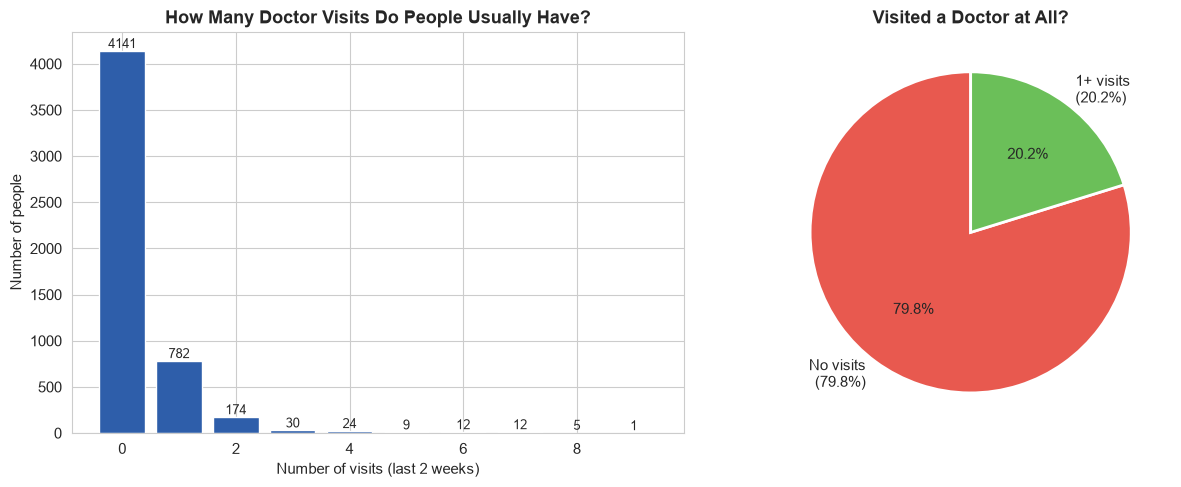

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

visit_counts = df["visits"].value_counts().sort_index()
axes[0].bar(visit_counts.index, visit_counts.values, color=PALETTE[0])
axes[0].set_title("How Many Doctor Visits Do People Usually Have?", fontweight="bold")
axes[0].set_xlabel("Number of visits (last 2 weeks)")
axes[0].set_ylabel("Number of people")
for i, v in zip(visit_counts.index, visit_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontsize=9)

zero_pct = (df["visits"] == 0).mean() * 100
labels = [f"No visits\n({zero_pct:.1f}%)", f"1+ visits\n({100-zero_pct:.1f}%)"]
axes[1].pie([zero_pct, 100 - zero_pct], labels=labels, colors=[PALETTE[3], PALETTE[4]],
            autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Visited a Doctor at All?", fontweight="bold")

plt.tight_layout()
plt.show()

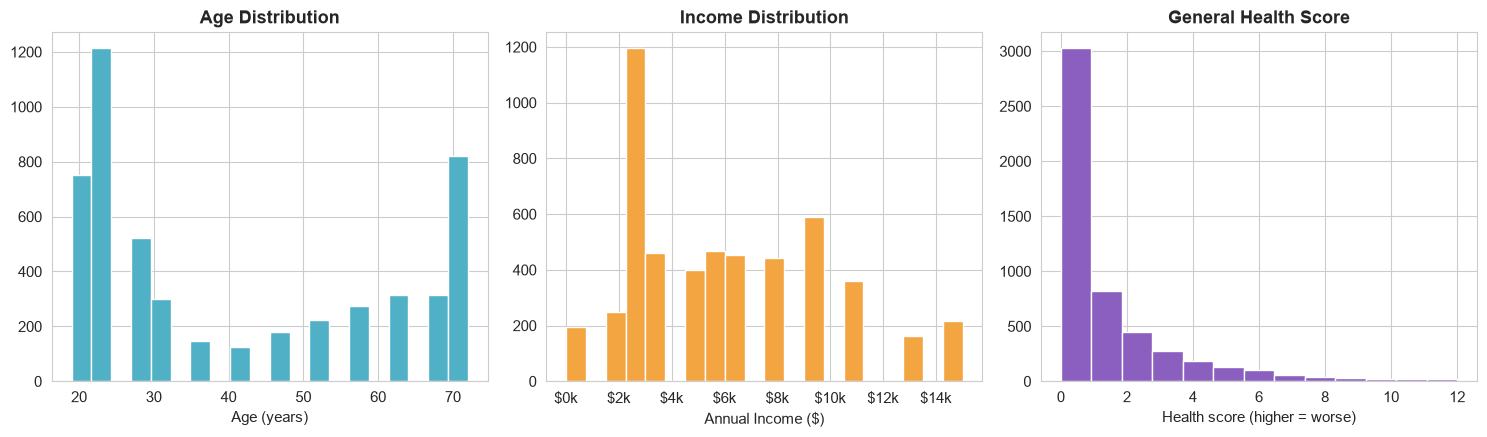

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df["age_years"], bins=20, color=PALETTE[1], edgecolor="white")
axes[0].set_title("Age Distribution", fontweight="bold")
axes[0].set_xlabel("Age (years)")

axes[1].hist(df["income_thousands"], bins=20, color=PALETTE[2], edgecolor="white")
axes[1].set_title("Income Distribution", fontweight="bold")
axes[1].set_xlabel("Annual Income ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}k"))

axes[2].hist(df["health"], bins=13, color=PALETTE[5], edgecolor="white")
axes[2].set_title("General Health Score", fontweight="bold")
axes[2].set_xlabel("Health score (higher = worse)")

plt.tight_layout()
plt.show()

# 4. Bivariate Analysis — Connecting Visits to Other Factors

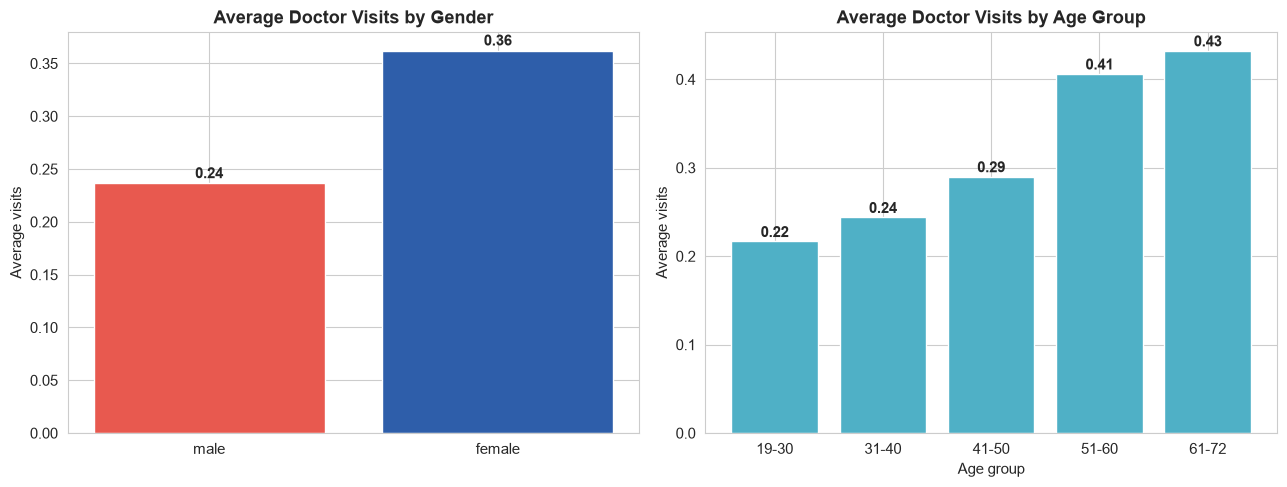

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

gender_visits = df.groupby("gender")["visits"].mean().sort_values()
axes[0].bar(gender_visits.index, gender_visits.values, color=[PALETTE[3], PALETTE[0]])
axes[0].set_title("Average Doctor Visits by Gender", fontweight="bold")
axes[0].set_ylabel("Average visits")
for i, v in enumerate(gender_visits.values):
    axes[0].text(i, v + 0.005, f"{v:.2f}", ha="center", fontweight="bold")

age_visits = df.groupby("age_group", observed=True)["visits"].mean()
axes[1].bar(age_visits.index.astype(str), age_visits.values, color=PALETTE[1])
axes[1].set_title("Average Doctor Visits by Age Group", fontweight="bold")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Average visits")
for i, v in enumerate(age_visits.values):
    axes[1].text(i, v + 0.005, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

The pattern is fairly clear: women visit the doctor a little more often than men on average, and visits rise steadily with age. The oldest group is almost three times as frequent as the youngest one.

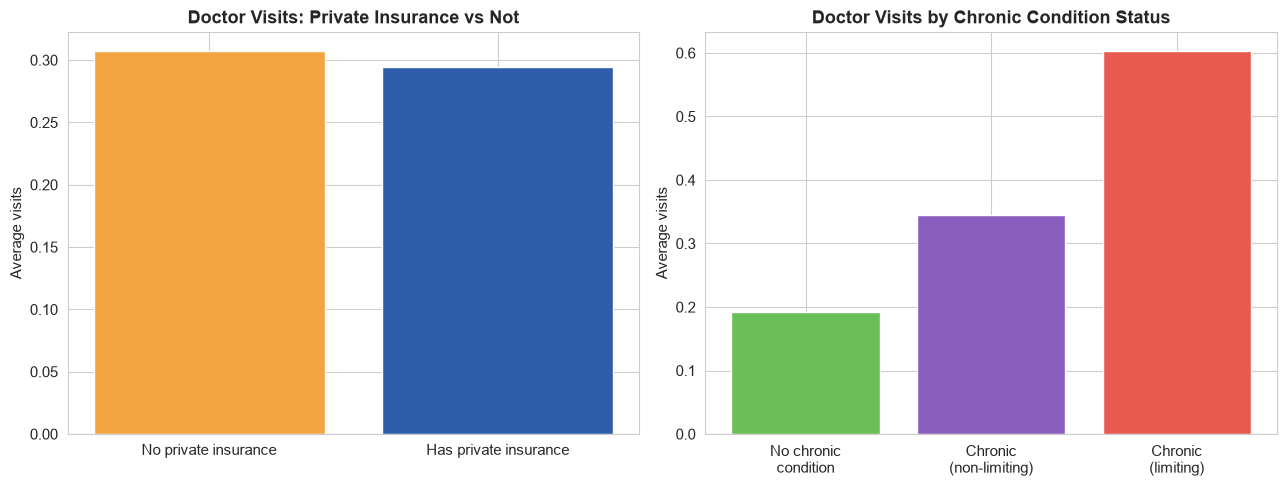

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

insurance_visits = df.groupby("private")["visits"].mean().sort_values()
axes[0].bar(["No private insurance", "Has private insurance"],
            [insurance_visits.get("no", 0), insurance_visits.get("yes", 0)],
            color=[PALETTE[2], PALETTE[0]])
axes[0].set_title("Doctor Visits: Private Insurance vs Not", fontweight="bold")
axes[0].set_ylabel("Average visits")

chronic_data = []
chronic_labels = []
for col, label in [("nchronic", "Chronic\n(non-limiting)"), ("lchronic", "Chronic\n(limiting)")]:
    chronic_data.append(df[df[col] == "yes"]["visits"].mean())
    chronic_labels.append(label)
chronic_data.insert(0, df[(df["nchronic"] == "no") & (df["lchronic"] == "no")]["visits"].mean())
chronic_labels.insert(0, "No chronic\ncondition")

axes[1].bar(chronic_labels, chronic_data, color=[PALETTE[4], PALETTE[5], PALETTE[3]])
axes[1].set_title("Doctor Visits by Chronic Condition Status", fontweight="bold")
axes[1].set_ylabel("Average visits")

plt.tight_layout()
plt.show()

People with a limiting chronic condition visit the doctor much more often than those without one. Private insurance also seems to make access a bit easier, which matches the pattern.

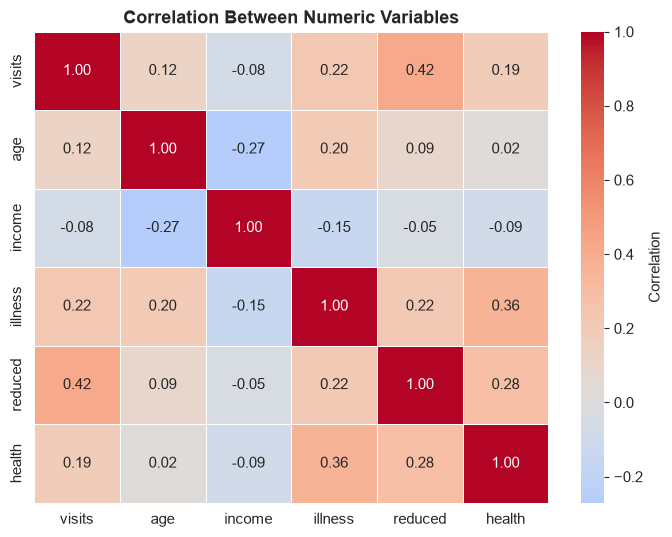

In [31]:
corr_cols = ["visits", "age", "income", "illness", "reduced", "health"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Between Numeric Variables", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# To know about the visits of man or women.

male_visits = df[df["gender"] == "male"]["visits"]
female_visits = df[df["gender"] == "female"]["visits"]

t_stat, p_val = stats.ttest_ind(male_visits, female_visits, equal_var=False)
print(f"Male average visits:   {male_visits.mean():.3f}")
print(f"Female average visits: {female_visits.mean():.3f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {p_val:.5f}")
print("=> Statistically significant difference" if p_val < 0.05 else "=> No statistically significant difference")

Male average visits:   0.236
Female average visits: 0.362
T-statistic: -5.722
P-value:     0.00000
=> Statistically significant difference


In [ ]:
# Chi-square test: is having a limiting chronic condition related to having private insurance

contingency = pd.crosstab(df["lchronic"], df["private"])
chi2, p_val2, dof, expected = stats.chi2_contingency(contingency)
print("Contingency table:")
print(contingency)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"P-value: {p_val2:.5f}")
print("=> Statistically significant relationship" if p_val2 < 0.05 else "=> No statistically significant relationship")

Contingency table:
private     no   yes
lchronic            
no        2518  2067
yes        374   231

Chi-square statistic: 10.036
P-value: 0.00154
=> Statistically significant relationship


In [34]:
import statsmodels.formula.api as smf

model_df = df.copy()
model_df["is_male"] = (model_df["gender"] == "male").astype(int)

for column in ["private", "nchronic", "lchronic"]:
    model_df[column] = (model_df[column] == "yes").astype(int)

poisson_model = smf.poisson(
    "visits ~ is_male + age + income + illness + reduced + health + private + nchronic + lchronic",
    data=model_df
).fit()

coeffs = poisson_model.params.drop("Intercept")
pvalues = poisson_model.pvalues.drop("Intercept")
pct_effect = (np.exp(coeffs) - 1) * 100

summary_table = pd.DataFrame({
    "Effect on visits (%)": pct_effect.round(1),
    "P-value": pvalues.round(4),
    "Significant?": pvalues < 0.05
}).sort_values("Effect on visits (%)", ascending=False)

summary_table = summary_table.reset_index().rename(columns={"index": "Predictor"})
summary_table[["Predictor", "Effect on visits (%)", "P-value", "Significant?"]].sort_values(
    "Effect on visits (%)", ascending=False
)

Optimization terminated successfully.
         Current function value: 0.647459
         Iterations 9


,Predictor,Effect on visits (%),P-value,Significant?
0,age,54.0,0.0022,True
1,illness,20.7,0.0000,True
2,lchronic,17.0,0.0548,False
3,reduced,13.5,0.0000,True
4,nchronic,12.6,0.0741,False
5,private,10.9,0.0533,False
6,health,3.1,0.0028,True
7,income,-15.3,0.0468,True
8,is_male,-15.8,0.0021,True


In [43]:
model_df = df.copy()
model_df["is_male"] = (model_df["gender"] == "male").astype(int)

for column in ["private", "nchronic", "lchronic"]:
    model_df[column] = (model_df[column] == "yes").astype(int)

poisson_model = smf.poisson(
    "visits ~ is_male + age + income + illness + reduced + health + private + nchronic + lchronic",
    data=model_df
).fit()

poisson_model.summary()

Optimization terminated successfully.
         Current function value: 0.647459
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Poisson Regression Results                          
==============================================================================
Dep. Variable:                 visits   No. Observations:                 5190
Model:                        Poisson   Df Residuals:                     5180
Method:                           MLE   Df Model:                            9
Date:                Sun, 20 Sep 2026   Pseudo R-squ.:                  0.1564
Time:                        17:13:46   Log-Likelihood:                -3360.3
converged:                       True   LL-Null:                       -3983.2
Covariance Type:            nonrobust   LLR p-value:                1.598e-262
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9992      0.096    -20.748      0.000      -2.188      -1.810
is_male       -0.1717      0.056     -3.080      0.002      -0.281      -0.062
age            0.4317      0.141      3.063      0.002       0.156       0.708
income        -0.1656      0.083     -1.988      0.047      -0.329      -0.002
illness        0.1878      0.018     10.288      0.000       0.152       0.224
reduced        0.1268      0.005     25.231      0.000       0.117       0.137
health         0.0301      0.010      2.992      0.003       0.010       0.050
private        0.1030      0.053      1.932      0.053      -0.001       0.208
nchronic       0.1186      0.066      1.786      0.074      -0.012       0.249
lchronic       0.1569      0.082      1.921      0.055      -0.003       0.317
==============================================================================
"""

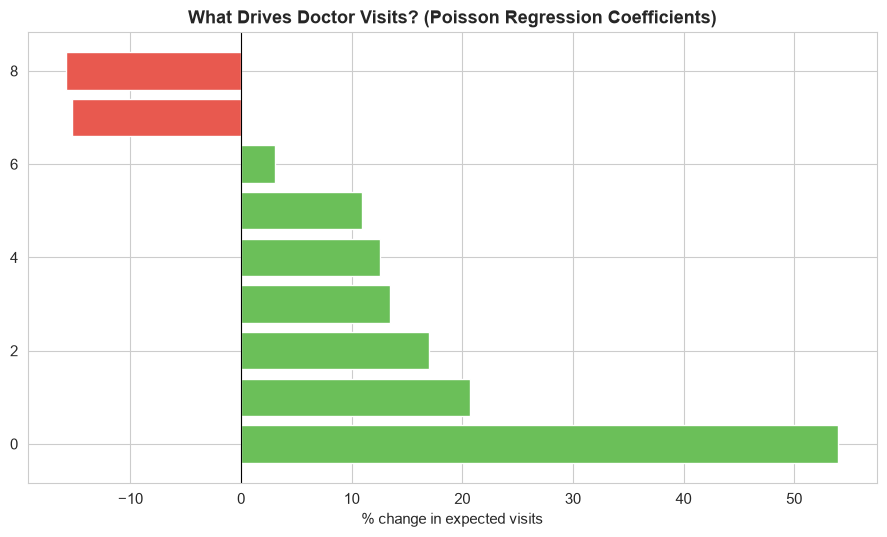

In [42]:
plt.figure(figsize=(9, 5.5))
colors = [PALETTE[4] if x > 0 else PALETTE[3] for x in summary_table["Effect on visits (%)"]]
plt.barh(summary_table.index, summary_table["Effect on visits (%)"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("What Drives Doctor Visits? (Poisson Regression Coefficients)", fontweight="bold")
plt.xlabel("% change in expected visits")
plt.tight_layout()
plt.show()

The strongest predictors are illness, reduced activity days, and general health score. A limiting chronic condition also raises expected visits noticeably.

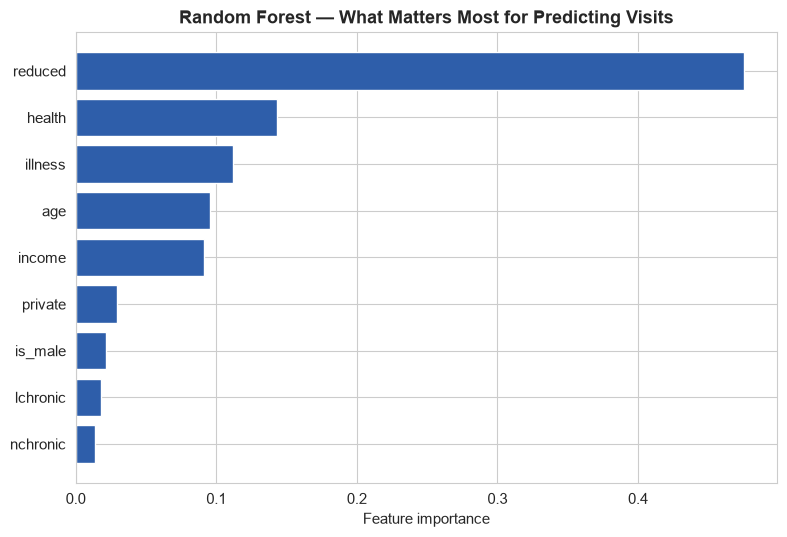

In [44]:
feat_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5.5))
plt.barh(feat_importance.index, feat_importance.values, color=PALETTE[0])
plt.title("Random Forest — What Matters Most for Predicting Visits", fontweight="bold")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

The Random Forest points in the same direction: illness, reduced activity days, and health are the main drivers, followed by age. Insurance status and gender matter much less in comparison.